# Tutorial for Hybrid Modeling of Entanglement Distribution Sources

In this tutorial, we will explore the complete process of modeling entanglement distribution sources using a hybrid Gaussian/non-Gaussian modeling approach. The fundamental theory for this approach can be found in (the accompanying paper that this code will be published with). To being, let's call the functions needed for modeling. ?

In [2]:
using Pkg
Pkg.instantiate()

┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\jomav\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\API.jl:1322
Precompiling packages...
   5649.4 ms  ✓ Genqo
  1 dependency successfully precompiled in 7 seconds. 192 already precompiled.


In [3]:
import Pkg; Pkg.add("Plots")

    Updating registry at `C:\Users\jomav\.julia\registries\General.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\jomav\OneDrive\Escritorio\Genqo.jl-1\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jomav\OneDrive\Escritorio\Genqo.jl-1\Manifest.toml`


In [2]:
using Genqo
using LinearAlgebra
using Plots

Matrix sparcity

In [10]:

function sparcity_ratio(μ::Real, ηᵗ::Real, ηᵈ::Real, ηᵇ::Real, dark_counts::Real)
    cov = Genqo.zalm.covariance_matrix(μ)
    A = Genqo.tools.k_function_matrix(cov) + Genqo.zalm.loss_bsm_matrix_pgen(ηᵗ, ηᵈ, ηᵇ)
    Ainv = inv(A)
    println("Ainv: ", size(Ainv,1))
   return count(!iszero, Ainv) / length(Ainv)
end
 sparcity_ratio(1e-2,1,1,1,1)

Ainv: 32


0.5

Recursive algorithm

In [13]:

function recursive_algorithm(A::Matrix{ComplexF64})
    nb_lines = size(A,1)

    if nb_lines % 2 != 0
        return 0
    end

    n = nb_lines ÷ 2

    z = zeros(ComplexF64, n * (2n - 1), n + 1)

    for j in 1:(2n - 1)
        ind = j * (j - 1) ÷ 2
        for k in 0:(j - 1)
            z[ind + k + 1, 1] = A[j + 1, k + 1]
        end
    end

    g = zeros(ComplexF64, n + 1)
    g[1] = one(ComplexF64)

    return solve_recursive(z, 2n, 1, g, n)
end


function solve_recursive(
    b::Matrix{ComplexF64},
    s::Int,
    w::Int,
    g::AbstractVector{ComplexF64},
    n::Int,
)

    if s == 0
        return w * g[n + 1]
    end

    c = zeros(ComplexF64, ((s - 2) * (s - 3)) ÷ 2, n + 1)

    i = 1

    for j in 1:(s - 3)
        for k in 0:(j - 1)
            src_row = ((j + 1) * (j + 2)) ÷ 2 + k + 3
            c[i, :] .= b[src_row, :]
            i += 1
        end
    end

    h = solve_recursive(c, s - 2, -w, g, n)

    e = copy(g)

    for u in 0:(n - 1)
        for v in 0:(n - u - 1)
            e[u + v + 2] += g[u + 1] * b[1, v + 1]
        end
    end

    for j in 1:(s - 3)
        for k in 0:(j - 1)
            c_row = j * (j - 1) ÷ 2 + k + 1

            for u in 0:(n - 1)
                for v in 0:(n - u - 1)
                    c[c_row, u + v + 2] +=
                        b[((j + 1) * (j + 2)) ÷ 2 + 1, u + 1] *
                        b[((k + 1) * (k + 2)) ÷ 2 + 2, v + 1] +
                        b[((k + 1) * (k + 2)) ÷ 2 + 1, u + 1] *
                        b[((j + 1) * (j + 2)) ÷ 2 + 2, v + 1]
                end
            end
        end
    end

    return h + solve_recursive(c, s - 2, w, e, n)
end

solve_recursive (generic function with 1 method)

In [32]:
function hafnian_sparse(A::AbstractMatrix{ComplexF64}; D::Union{Nothing, Set{Int}}=nothing, loop::Bool=false)  
    n = size(A, 1)

    Dset = D === nothing ? Set(1:n) : Set(D)

    B = copy(A)
    if !loop
        for i in 1:n
            B[i, i] = zero(ComplexF64)
        end
    end

    # Python: if np.allclose(A, 0): return 0.0
    if all(x -> isapprox(x, zero(ComplexF64); atol=1e-12, rtol=1e-12), B)
        return zero(ComplexF64)
    end

    # Memoization cache.
    # Use sorted tuples as keys because Set is mutable and unsafe as a Dict key.
    cache = Dict{Tuple{Vararg{Int}}, ComplexF64}()

    function lhaf(d::Set{Int})::ComplexF64
        key = Tuple(sort(collect(d)))

        if haskey(cache, key)
            return cache[key]
        end

        if isempty(d)
            return one(ComplexF64)
        end

        d_without_k = copy(d)
        k = pop!(d_without_k)

        # Python: indices(d, k) = d ∩ nonzero(A[k, :])
        nonzero_cols = findall(j -> !iszero(B[k, j]), 1:n)
        js = intersect(d, Set(nonzero_cols))

        result = zero(ComplexF64)
        for j in js
            next_d = setdiff(d_without_k, Set([j]))
            result += B[j, k] * lhaf(next_d)
        end

        cache[key] = result
        return result
    end

    return lhaf(Dset)
end

hafnian_sparse (generic function with 2 methods)

Batched algorithm

In [3]:

#cutoff shoould be able to be array or Int 
function hafnian_batched(A::Matrix{ComplexF64}, cutoff::Int, mu::vector{}, rtol::Float64 = 1e-05, atol::Float64 = 1e-08, renom::Bool = false, make_tensor::Bool = true)
   n = size(A, 1)

   if isempty(mu)
       mu = zeros(ComplexF64, n)
   end

    return hermite_multidimensional(R=-A, cutoff=cutoff, y=mu, renorm=renorm, make_tensor=make_tensor, modified=true)
end

function hermite_multidimensional(R::Matrix{ComplexF64}, cutoff::Int, y::Union{Nothing,AbstractVector}=nothing, C::ComplexF64=1, renorm::Bool=False, make_tensor::Bool=True, modified::Bool=False, rtol::Float64=1e-05, atol::Float64=1e-08)
    n = size(R, 1)

    if !modified && y !== nothing
        m = size(y, 1)
        if m == n
            ym = R * y
            return hermite_multidimensional(R=R, cutoff=cutoff, y=ym, C=C, renorm=renorm, make_tensor=make_tensor, modified=true)
        end
    end

    if y === nothing
        y = zeros(ComplexF64, n)
    end

    m = size(y, 1)
    #Not sure if I shoudld keep this.
    if m != n
        throw(ArgumentError("The matrix R and vector y have incompatible dimensions"))
    end

    num_indices = length(y)

    cutoff =
        if cutoff isa AbstractArray && length(cutoff) == 1
            ntuple(_ -> Int(first(cutoff)), num_indices)
        elseif cutoff isa Integer
            ntuple(_ -> Int(cutoff), num_indices)
        else
            Tuple(Int.(cutoff))
        end

    Rt = real_if_close(R)
    yt = real_if_close(y)

    T = promote_type(eltype(Rt), eltype(yt), eltype(C))
    array = zeros(T, cutoff)

    array[ntuple(_ -> 1, num_indices)...] = C

    values = 
        if renorm 
            Array(_hermite_multidimensional_renorm(Rt, yt, array))
        else 
            Array(_hermite_multidimensional(Rt, yt, array))
        end

    if !make_tensor
        values = vec(values)
    end
    return values

end

function _hermite_multidimensional_renorm(R::Matrix{T}, y::Vector{T}, G::Array{T, N}) where {T, N}
    shape = size(G)
    shape_arr = collect(shape)
    D = length(y)
    # calculate the strides (e.g. (100,10,1) for shape (10,10,10))
    
    strides = ones(Int, D)

    for i in (D-1):-1:1
        strides[i] = strides[i + 1] * shape_arr[i + 1]
    end

    total_size = prod(shape)
    Gflat = zeros(eltype(G), total_size)

    # Copy G into the row-major flat buffer
    for flat_index in 0:(total_size - 1)
        idx0 = rowmajor_index(flat_index, shape_arr, strides)
        idx1 = Tuple(i + 1 for i in idx0)
        Gflat[flat_index + 1] = G[idx1...]
    end

     # Iterate over the indices smaller than max(strides) with pivot bound check.
    # The check is needed only if the flat index is smaller than the largest stride.
    # Afterwards it will be safe to get the pivot by subtracting the first (largest) stride.
    for flat_index in 1:(strides[1] - 1)
        index = rowmajor_index(flat_index, shape_arr, strides)
        i = 1

        for s in strides
            pivot = flat_index - s
            if pivot >= 0 
                break
            end
            i += 1
        end
        value_at_index = y[i] * Gflat[pivot + 1]

        # Contribution from pivot's lower neighbours
        value_at_index -= R[i, i] * sqrt(index[i] - 1) * Gflat[pivot - strides[i] + 1]
        for j in i+1:D 
            value_at_index -= R[i,j] * sqrt(index[j]) * Gflat[pivot - strides[j] + 1]
        end

        Gflat[flat_index + 1] = value_at_index/sqrt(index[i])

    end

    # Iterate over the rest of the indices.
    for flat_index in strides[1]:(total_size - 1)
        index = rowmajor_index(flat_index, shape_arr, strides)

        pivot = flat_index - strides[1]

        value_at_index = y[1] * Gflat[pivot + 1]
        #Contribution from pivot's lower neighbours
        value_at_index -= R[1, 1] *sqrt(index[1] - 1) * Gflat[pivot - strides[1] + 1]
        for j in 2:D
            value_at_index -= R[1, j] * sqrt(index[j]) * Gflat[pivot - strides[j] + 1]
        end

        Gflat[flat_index + 1] = value_at_index / sqrt(index[1])
    end
    out = similar(G)

    for flat_index in 0:(total_size - 1)
        idx0 = rowmajor_index(flat_index, shape_arr, strides)
        idx1 = Tuple(i + 1 for i in idx0)
        out[idx1...] = Gflat[flat_index + 1]
    end

    return out
end

function rowmajor_index(flat_index::Int, shape_arr::Vector{Int}, strides::Vector{Int})
    D = length(shape_arr)
    index = Vector{Int}(undef, D)

    for k in 1:D
        index[k] = div(flat_index, strides[k]) % shape_arr[k]
    end

    return index
end

function _hermite_multidimensional(R::Matrix{T}, y::Vector{T}, G::Array{T, N}) where {T, N}
    shape = size(G) 
    D = length(shape)
    indices = CartesianIndices(D)

    for idx in Iterators.drop(indices, 1)
        idx_tuple = Tuple(idx)

        i = 1
        for j in 1:D
            if idx_tuple[j] > 1
                i = j
                break
            end
        end
        ki = ntuple(j -> j == i ? idx_tuple[j] - 1 : idx_tuple[j], D)

        u = y[i] * G[ki...]
         for l in 1:D
            if ki[l] > 1
                kl = ntuple(j -> j == l ? ki[j] - 1 : ki[j], D)
                u -= (ki[l] - 1) * R[i, l] * G[kl...]
            end
        end

        G[idx_tuple...] = u
    end

    return G
end


UndefVarError: UndefVarError: `vector` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [33]:
function Ainv(μ::Real, ηᵗ::Real, ηᵈ::Real, ηᵇ::Real, dark_counts::Real)
    cov = Genqo.zalm.covariance_matrix(μ)
    A = Genqo.tools.k_function_matrix(cov) + Genqo.zalm.loss_bsm_matrix_pgen(ηᵗ, ηᵈ, ηᵇ)
    return inv(A)
end

A = Ainv(1e-2,1,1,1,1)
recursive_algorithm(A)

3.8103520315373697e-16 + 0.0im

In [34]:
hafnian_sparse(A)

3.810270131823998e-16 + 0.0im

Benchmark


In [ ]:
using BenchmarkTools
using Random
using Statistics

In [ ]:

function random_complex_symmetric_matrix(n::Int)
    A = randn(ComplexF64, n, n)
    return (A + transpose(A)) / 2
end
function benchmark_hafnian_sizes(sizes::Vector{Int}; samples::Int = 10)
    times = Float64[]

    for N in sizes
        println("Benchmarking matrix size $N x $N")
        A = random_complex_symmetric_matrix(N)
        recursive_algorithm(A)
        bench = @benchmark recursive_algorithm($A) samples=samples evals=1
        push!(times, median(bench.times) / 1e9)
    end

    return times
end

sizes = collect(2:2:24) 
times = benchmark_hafnian_sizes(sizes; samples=100)

plot(
    sizes,times,marker=:circle, xlabel="Matrix size N", ylabel="Median runtime, seconds",title="Recursive Hafnian Benchmark",label="recursive_algorithm", legend=:bottomright, yscale=:log10,
)

In [1]:
using Plots

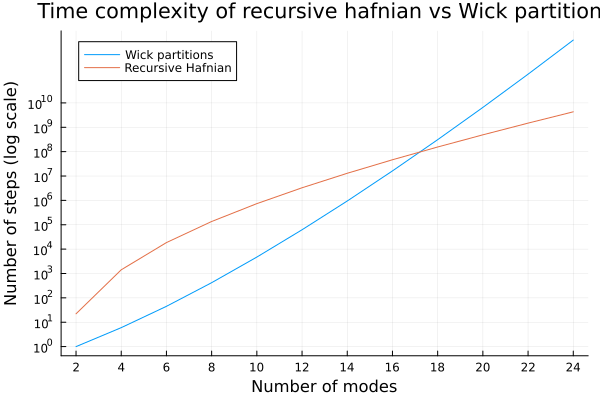

In [18]:
using Plots

wick_partition_compx = [
    1,
    3*2,
    5*3*3,
    7*5*3*4,
    9*7*3*5*5,
    11*9*7*5*3*6,
    13*11*9*7*5*3*7,
    15*13*11*9*7*5*3*8,
    17*15*13*11*9*7*5*3*9,
    19*17*15*13*11*9*7*5*3*10,
    21*19*17*15*13*11*9*7*5*3*11,
    23*21*19*17*15*13*11*9*7*5*3*12
]

x = [2,4,6,8,10,12,14,16,18,20,22,24]

recursive_hafnian_compx(n) = n^4 * log(n) * 2^(n/2)

recursive_hafnian = recursive_hafnian_compx.(x)

plot(x, wick_partition_compx, label="Wick partitions", legend=:topleft,    xticks = 0:2:24)
plot!(x, recursive_hafnian, label="Recursive Hafnian")
plot!(yscale=:log10, lw=3)
plot!(yticks = 10 .^ (0:10))

title!("Time complexity of recursive hafnian vs Wick partitions")
ylabel!("Number of steps (log scale)")
xlabel!("Number of modes")
